## **1. Introduction**
The goal of this notebook is to apply traditional data augmentation techniques to the training and calibration datasets.

## **2. Libraries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Library
import os
import sys
import torch
import random
import warnings
import cv2 as cv
import numpy as np
import torchvision
import pandas as pd
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
from torchvision.io import read_image
from torchvision.io import ImageReadMode #Necessary to correctly importing the image by torchvision.read_image
from transformers import AutoImageProcessor
from sklearn.model_selection import train_test_split
from datasets import load_dataset, Image, DatasetDict, Dataset, ClassLabel


# Local Modules
sys.path.append('/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/utils')

from general_utils import (
    image_path_generation,
    plot_label_distribution,
)

from dataaugmentation_utils import (augment_and_save_image,
                   balance_classes_and_augment,
                   plot_original_and_transformed,
                   train_transforms)

warnings.filterwarnings('ignore')

## **3. Load data and split data**

In [3]:
# Define the base path for images
dataset_path = '/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/'
file_name = 'WM_811k_subset.csv'

# Load dataset
df = pd.read_csv(dataset_path + file_name, index_col=0)

# Generate full image paths by passing base_image_path to the function via lambda
df['image_id'] = df.apply(lambda row: image_path_generation(row, base_path=dataset_path), axis=1)

df.shape

(10860, 7)

In [4]:
# Split the main DataFrame into separate datasets: train, val, test
datasets = {}
for split in ['train', 'val', 'test', 'cal']:
    subset = df[df['set'] == split].reset_index(drop=True)
    datasets[split] = subset
    print(f"{split} shape: {subset.shape}")

# Assign individual datasets for easier access
train = datasets['train']
valid = datasets['val']
test = datasets['test']
cal = datasets['cal']

# Drop unnecessary columns from each dataset
cols_to_drop = ['wf_id', 'dieSize', 'lotid', 'image', 'set']
train = train.drop(cols_to_drop, axis=1)
valid = valid.drop(cols_to_drop, axis=1)
test = test.drop(cols_to_drop, axis=1)
cal = cal.drop(cols_to_drop, axis=1)

train shape: (5907, 7)
val shape: (1304, 7)
test shape: (2172, 7)
cal shape: (1477, 7)


## **Data augmentation**

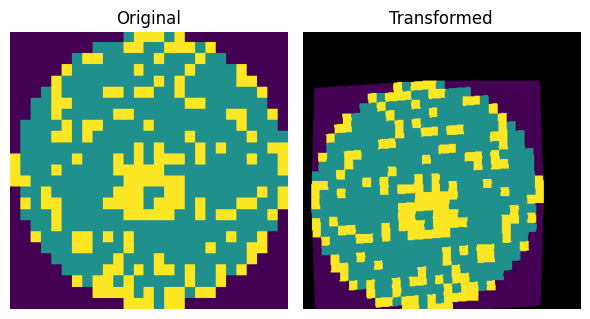

In [5]:
plot_original_and_transformed(train.image_id[0], train_transforms)

In [7]:
# Create the subfolders
base_path = '/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/'
save_dir_train  = f'{base_path}/dataaugmented/train'
save_dir_calib  = f'{base_path}/dataaugmented/cal'

Path(save_dir_train ).mkdir(parents=True, exist_ok=True)
Path(save_dir_calib ).mkdir(parents=True, exist_ok=True)

In [8]:
# Convert save directories to Path objects
save_dir_train = Path(save_dir_train)
save_dir_calib = Path(save_dir_calib)

# Create the full output path for the augmented training file
output_name_train = 'train_augmented.csv'
output_path_train = save_dir_train / output_name_train

# Create the full output path for the augmented calibration file
output_name_calib = 'calib_augmented.csv'
output_path_calib = save_dir_calib / output_name_calib

# Print to verify the output paths
print(output_path_train)
print(output_path_calib)

/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/dataaugmented/cal/calib_augmented.csv


In [9]:
from pathlib import Path

# Define the base path for the dataset
base_path = Path('/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset')

# Define directories for augmented training and calibration data
save_dir_train = base_path / 'dataaugmented' / 'train'
save_dir_calib = base_path / 'dataaugmented' / 'cal'

# Create the directories if they do not exist
save_dir_train.mkdir(parents=True, exist_ok=True)
save_dir_calib.mkdir(parents=True, exist_ok=True)

# Define output paths for the augmented CSV files
#output_path_train = save_dir_train / 'train_augmented.csv'
output_path_calib = save_dir_calib / 'calib_augmented.csv'

# Print the paths to verify
print(f"Training output path: {output_path_train}")
print(f"Calibration output path: {output_path_calib}")


Calibration output path: /content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/dataaugmented/cal/calib_augmented.csv


In [10]:
print(train['labels'].value_counts().max())
print(cal['labels'].value_counts().max())

562


In [ ]:

# Balance the classes by oversampling up to 200 examples per class
tgt_cnt = train['labels'].value_counts().max()

# Apply data augmentation to reach the target count for each class
# The augmented images will be saved in the specified directory
# and the corresponding updated DataFrame will be saved to CSV
balance_classes_and_augment(
    train,
    target_count=tgt_cnt,
    save_dir=save_dir_train,
    transform=train_transforms,
    output_path=output_path_train
)


Streaming output truncated to the last 5000 lines.
Processing Classes: 100%|██████████| 7/7 [52:11<00:00, 447.31s/it]


Total new images saved: 12093


,image_id,labels
0,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc
1,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc
2,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc
3,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc
4,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc
...,...,...
12088,/content/drive/MyDrive/Conformal_Prediction_Re...,Near-full
12089,/content/drive/MyDrive/Conformal_Prediction_Re...,Near-full
12090,/content/drive/MyDrive/Conformal_Prediction_Re...,Near-full
12091,/content/drive/MyDrive/Conformal_Prediction_Re...,Near-full


In [11]:
tgt_cnt = cal['labels'].value_counts().max()
balance_classes_and_augment(cal, target_count = tgt_cnt, save_dir=save_dir_calib, transform=train_transforms, output_path=output_path_calib)

Processing Classes: 100%|██████████| 7/7 [16:08<00:00, 138.37s/it]


Total new images saved: 3019


,image_id,labels
0,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc
1,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc
2,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc
3,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc
4,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc
...,...,...
3014,/content/drive/MyDrive/Conformal_Prediction_Re...,Near-full
3015,/content/drive/MyDrive/Conformal_Prediction_Re...,Near-full
3016,/content/drive/MyDrive/Conformal_Prediction_Re...,Near-full
3017,/content/drive/MyDrive/Conformal_Prediction_Re...,Near-full
